## Worked Example: Kuhn Poker
From the paper "An Introduction to Counterfactual Regret Minimization" by Todd W. Neller and Marc Lanctot, Section 3.4.

In [1]:
import numpy as np
from tqdm import tqdm

np.random.seed(2)  # For reproducibility

In [2]:
# actions
PASS = 0
BET = 1
NUM_ACTIONS = 2

# cards
CARDS = [1, 2, 3]

# information set node storage
# key: infoset string (card + history), value: dict with regret_sum, strategy, strategy_sum
node_map = {}

def get_node(info_set):
    """Retrieve the node for an infoset, creating it if it doesn't exist."""
    if info_set not in node_map:
        node_map[info_set] = {
            "regret_sum": np.zeros(NUM_ACTIONS),
            "strategy": np.zeros(NUM_ACTIONS),
            "strategy_sum": np.zeros(NUM_ACTIONS),
        }
    return node_map[info_set]

In [3]:
def get_strategy(node, realization_weight):
    """Get the current strategy for a node based on regret matching, and accumulate it into strategy_sum."""
    normalizing_sum = 0

    # first pass to sum up the positive regrets
    for a in range(NUM_ACTIONS):
        node["strategy"][a] = max(0, node["regret_sum"][a])
        normalizing_sum += node["strategy"][a]

    # second pass to normalize the strategy if any positive regrets exist, otherwise use uniform strategy
    for a in range(NUM_ACTIONS):
        if normalizing_sum > 0:
            node["strategy"][a] /= normalizing_sum
        else:
            node["strategy"][a] = 1.0 / NUM_ACTIONS
        node["strategy_sum"][a] += realization_weight * node["strategy"][a]
    return node["strategy"]

In [4]:
def get_average_strategy(node):
    """Get the average strategy for a node over all training iterations."""
    avg_strategy = np.zeros(NUM_ACTIONS)
    normalizing_sum = 0

    for a in range(NUM_ACTIONS):
        normalizing_sum += node["strategy_sum"][a]
    for a in range(NUM_ACTIONS):
        if normalizing_sum > 0:
            avg_strategy[a] = node["strategy_sum"][a] / normalizing_sum
        else:
            avg_strategy[a] = 1.0 / NUM_ACTIONS
    return avg_strategy

In [5]:
def cfr(cards, history, p0, p1):
    """One recursive counterfactual regret minimization pass over the Kuhn poker game tree."""
    plays = len(history)
    player = plays % 2
    opponent = 1 - player

    # return payoff for terminal states
    if plays > 1:
        terminal_pass = history[-1] == "p"
        double_bet = history[-2:] == "bb"
        is_player_card_higher = cards[player] > cards[opponent]
        if terminal_pass:
            if history == "pp":
                return 1 if is_player_card_higher else -1
            else: # history is "bp"
                return 1
        elif double_bet:
            return 2 if is_player_card_higher else -2

    info_set = str(cards[player]) + history
    node = get_node(info_set)

    # get regret-matched mixed-strategy actions
    strategy = get_strategy(node, p0 if player == 0 else p1)
    util = np.zeros(NUM_ACTIONS)
    node_util = 0

    # for each action, recursively call cfr with additional history and probability
    for a in range(NUM_ACTIONS):
        next_history = history + ("p" if a == 0 else "b")
        if player == 0:
            util[a] = -cfr(cards, next_history, p0 * strategy[a], p1)
        else:
            util[a] = -cfr(cards, next_history, p0, p1 * strategy[a])
        node_util += strategy[a] * util[a]

    # for each action, compute and accumulate counterfactual regret
    for a in range(NUM_ACTIONS):
        regret = util[a] - node_util
        node["regret_sum"][a] += (p1 if player == 0 else p0) * regret

    return node_util

In [6]:
def train(iterations, log_interval=1000):
    """Train the Kuhn poker CFR agent, logging average game value and per-infoset strategies."""
    cards = [1, 2, 3]
    util_total = 0
    game_value_history = []
    strategy_history = []

    for i in tqdm(range(iterations)):
        np.random.shuffle(cards)
        util_total += cfr(cards, "", 1, 1)

        if i % log_interval == 0:
            game_value_history.append(util_total / (i + 1))
            strategy_history.append(
                {info_set: get_average_strategy(node).copy() for info_set, node in node_map.items()}
            )

    return game_value_history, strategy_history

In [7]:
game_value_history, strategy_history = train(2000000)
print(f"Average game value (player 1): {game_value_history[-1]:.4f}")
print(f"Expected (analytical): {-1/18:.4f}\n")

for info_set in sorted(node_map.keys()):
    print(f"{info_set:>4}: {get_average_strategy(node_map[info_set])}")

100%|██████████| 2000000/2000000 [00:25<00:00, 79525.76it/s]

Average game value (player 1): -0.0533
Expected (analytical): -0.0556

   1: [0.73978291 0.26021709]
  1b: [9.99997752e-01 2.24755129e-06]
  1p: [0.66770488 0.33229512]
 1pb: [9.99999492e-01 5.07624769e-07]
   2: [9.99970960e-01 2.90404681e-05]
  2b: [0.66141794 0.33858206]
  2p: [9.99985576e-01 1.44241216e-05]
 2pb: [0.40785148 0.59214852]
   3: [0.22226149 0.77773851]
  3b: [7.51515807e-07 9.99999248e-01]
  3p: [7.51515807e-07 9.99999248e-01]
 3pb: [1.68395516e-06 9.99998316e-01]


## plotting

In [8]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns

OFF_WHITE = "#F9F9F6"
INK = "#222222"
BLUE = "#2F4A8A"
RED = "#B04444"

sns.set_theme(
    style="whitegrid",
    font_scale=0.8,
    rc={'figure.facecolor': OFF_WHITE, 'axes.facecolor': OFF_WHITE}
)

iters = np.arange(len(strategy_history)) * 1000
cards_order = ["1", "2", "3"]
history_order = ["", "p", "b", "pb"]  # the 4 non-terminal decision points per card

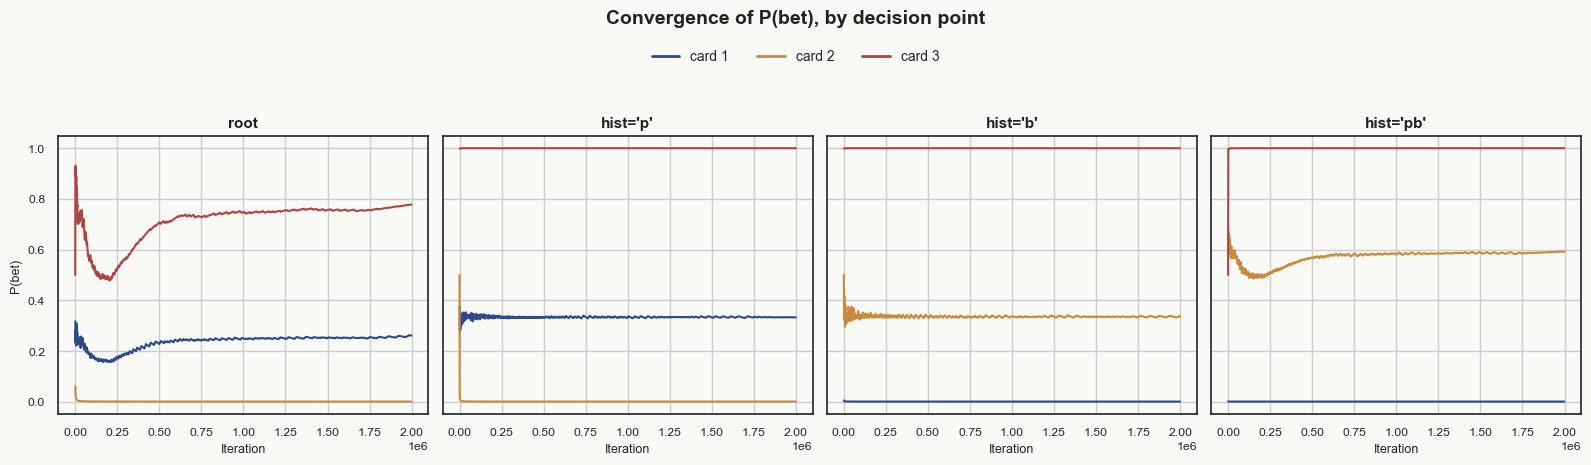

In [9]:
CARD_COLORS = {"1": BLUE, "2": "#C98A3B", "3": RED}

fig1, axes1 = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True, facecolor=OFF_WHITE)

for col, hist in enumerate(history_order):
    ax = axes1[col]
    ax.set_facecolor(OFF_WHITE)

    for card in cards_order:
        info_set = card + hist
        bet_probs = [snap.get(info_set, [np.nan, np.nan])[1] for snap in strategy_history]
        ax.plot(iters, bet_probs, color=CARD_COLORS[card], linewidth=1.5, label=f"card {card}")

    ax.set_ylim(-0.05, 1.05)
    title = "root" if hist == "" else f"hist='{hist}'"
    ax.set_title(title, fontsize=11, fontweight="bold", color=INK)
    ax.set_xlabel("Iteration", fontsize=9, color=INK)
    if col == 0:
        ax.set_ylabel("P(bet)", fontsize=9, color=INK)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_color(INK)

card_handles = [mlines.Line2D([], [], color=CARD_COLORS[c], linewidth=2, label=f"card {c}") for c in cards_order]
fig1.legend(handles=card_handles, loc="upper center", ncol=3, frameon=False,
            fontsize=10, bbox_to_anchor=(0.5, 1.08))
fig1.suptitle("Convergence of P(bet), by decision point", fontsize=14, fontweight="bold", color=INK, y=1.15)
plt.tight_layout()
plt.show()

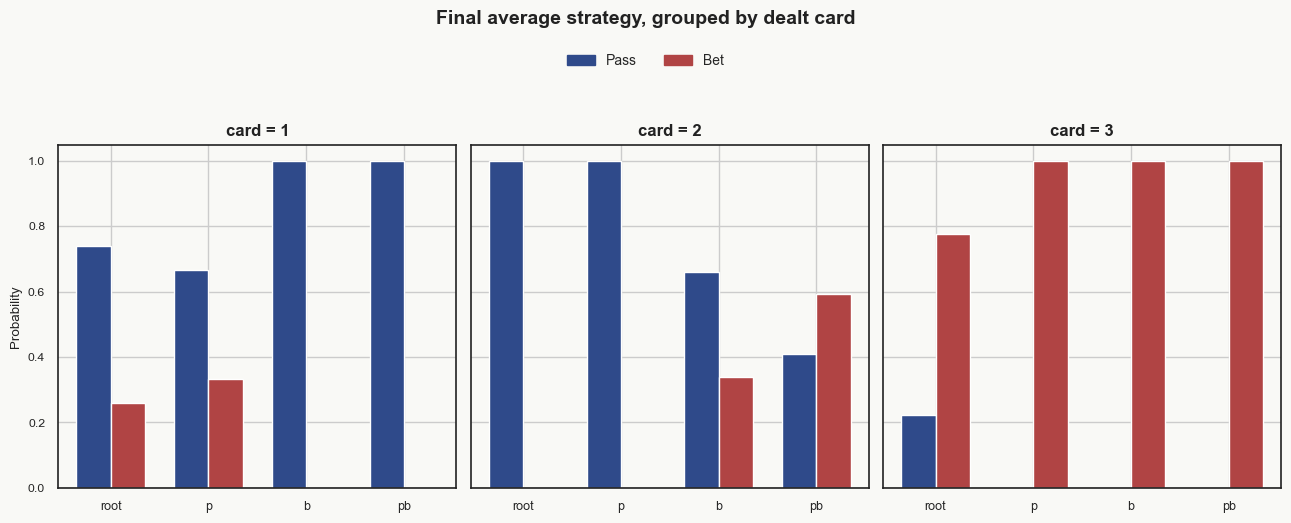

In [10]:
fig2, axes2 = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True, facecolor=OFF_WHITE)

for i, card in enumerate(cards_order):
    ax = axes2[i]
    ax.set_facecolor(OFF_WHITE)

    pass_probs = [get_average_strategy(node_map[card + h])[0] if (card + h) in node_map else np.nan for h in history_order]
    bet_probs = [get_average_strategy(node_map[card + h])[1] if (card + h) in node_map else np.nan for h in history_order]

    x = np.arange(len(history_order))
    width = 0.35
    ax.bar(x - width/2, pass_probs, width, color=BLUE, label="Pass")
    ax.bar(x + width/2, bet_probs, width, color=RED, label="Bet")

    ax.set_xticks(x)
    ax.set_xticklabels(["root" if h == "" else h for h in history_order], fontsize=9)
    ax.set_title(f"card = {card}", fontsize=12, fontweight="bold", color=INK)
    ax.axhline(0, color=INK, linewidth=0.8)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_color(INK)
    if i == 0:
        ax.set_ylabel("Probability", color=INK)

pass_patch = mpatches.Patch(color=BLUE, label="Pass")
bet_patch = mpatches.Patch(color=RED, label="Bet")
fig2.legend(handles=[pass_patch, bet_patch], loc="upper center", ncol=2, frameon=False,
            fontsize=10, bbox_to_anchor=(0.5, 1.08))
fig2.suptitle("Final average strategy, grouped by dealt card", fontsize=14, fontweight="bold", color=INK, y=1.15)
plt.tight_layout()
plt.show()